# TP B7 (volet ML) — Optuna borné, CodeCarbon et SHAP sur la détection de pannes

## Objectif concret et point de départ

Ce notebook reprend le **RandomForest de maintenance prédictive** (retenu et déjà tuné une première fois
dans `07-maintenance-optimisation-optuna-mlflow.ipynb`) sous **trois angles** : une étude Optuna *bornée et
avec pruning* (le notebook 07 utilisait `NopPruner`, sans budget temps), une mesure **CodeCarbon** du coût
énergétique, et une explication **SHAP** des décisions du modèle. Toute la logique réutilisable a été
**industrialisée** dans `src/indusense/fault/` (Chantier 2 du TP B7) : ce notebook **importe** ces modules
et se limite à l'orchestration, aux figures et aux commentaires.

**Écart assumé avec la consigne.** La consigne générique du TP B7 part d'un **XGBoost**. Ce projet n'a
jamais entraîné de XGBoost : les notebooks `01` à `07` ont comparé régression logistique, RandomForest et
HistGradientBoosting, et retenu **RandomForestClassifier** (voir `04-maintenance-comparaison-trois-modeles.ipynb`).
Le principe même du TP B7 (« on repart de vos modèles, on ne change pas le problème ») impose de garder ce
RandomForest plutôt que d'introduire un XGBoost artificiel. `shap.TreeExplainer` fonctionne nativement avec
un RandomForest : la partie explicabilité n'est donc pas affectée par ce choix.

**Une machine-heure** est l'état d'une machine pendant une heure. La cible `label_failure_next_24h` vaut 1
lorsqu'une panne surviendra dans les 24 heures suivantes.

**Prérequis observables :** le CSV Gold est présent (`datas/gold_dataset_20260622-080603.csv`), l'environnement
`.venv` contient les groupes `dev` et `ml` (`shap`, `codecarbon`, en plus d'`optuna`/`mlflow` déjà présents), et
le package `indusense.fault` est installé (`uv sync`, backend `uv_build`, mode éditable).

**Livrables de cette exécution :** un historique Optuna avec essais élagués (pruning), un tableau
`durée / kWh / gCO2eq / performance` comparant une étude lourde et une étude frugale, un summary plot et un
waterfall SHAP commentés, et un tableau d'arbitrage final.

In [1]:
from pathlib import Path
import logging
import os
import warnings
from importlib.metadata import version
from time import perf_counter

os.environ['MLFLOW_DISABLE_AGENT_HINT'] = '1'
for logger_name in ('mlflow', 'mlflow.sklearn', 'mlflow.utils.environment', 'mlflow.utils.uv_utils'):
    logging.getLogger(logger_name).setLevel(logging.ERROR)
warnings.filterwarnings('ignore', message=r'Hint: Inferred schema contains integer column.*',
                        category=UserWarning, module=r'mlflow\.types\.utils')

import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import optuna
import pandas as pd
import shap
from IPython.display import Markdown, display

from indusense.fault import carbon, data, evaluate, explain, model, train, tune

optuna.logging.set_verbosity(optuna.logging.WARNING)

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
STORE = ROOT / '.mlflow'
STORE.mkdir(exist_ok=True)
ARTIFACTS = STORE / 'artifacts'
ARTIFACTS.mkdir(exist_ok=True)
mlflow.set_tracking_uri('sqlite:///' + (STORE / 'mlflow.db').as_posix())
EXPERIMENT = 'indusense-fault-pipeline'
if mlflow.get_experiment_by_name(EXPERIMENT) is None:
    mlflow.create_experiment(EXPERIMENT, artifact_location=ARTIFACTS.as_uri())
experiment = mlflow.set_experiment(EXPERIMENT)

OUTPUT_DIR = ROOT / 'outputs' / 'fault'
FIGURES_DIR = OUTPUT_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42

versions = {p: version(p) for p in ['optuna', 'mlflow', 'scikit-learn', 'shap', 'codecarbon']}
display(pd.DataFrame({'Composant': list(versions) + ['Expérience MLflow'],
                      'Valeur': list(versions.values()) + [EXPERIMENT]}))
print('ENVIRONNEMENT_PRET : optuna, mlflow, shap et codecarbon sont chargés.')

D:\source\A4U\FormationIA\indusense\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Composant,Valeur
0,optuna,5.0.0
1,mlflow,3.16.0
2,scikit-learn,1.9.1
3,shap,0.52.0
4,codecarbon,3.3.1
5,Expérience MLflow,indusense-fault-pipeline


ENVIRONNEMENT_PRET : optuna, mlflow, shap et codecarbon sont chargés.


## 1. Rappel de la baseline RandomForest

Le split temporel et la purge anti-fuite viennent de `indusense.fault.data` : `temporal_split` retire, aux
frontières train/validation et validation/test, toute ligne dont la fenêtre se situe à moins de 24 h (l'horizon
prédit) du rôle suivant. `build_cv_folds` découpe ensuite le train en 3 folds **chronologiques** (jamais un
`KFold` aléatoire, qui mélangerait passé et futur et gonflerait artificiellement le score).

La baseline reprend `BASELINE_PARAMS` de `indusense.fault.model` — les mêmes hyperparamètres que la
référence manuelle du notebook 07.

In [2]:
gold = data.load_gold(data.DEFAULT_DATA_PATH)
split = data.temporal_split(gold, horizon=24)
folds = data.build_cv_folds(split, n_folds=3)

fold_table = pd.DataFrame(folds.metadata)
display(fold_table.style.hide(axis='index'))
print(f"{len(split.features)} features, {len(split.X['train'])} lignes de train, "
      f"{len(split.X['test'])} lignes de test.")

def fit_baseline():
    return train.fit_and_log(
        model.BASELINE_PARAMS, split.X['train'], split.y['train'], folds,
        role='reference', seed=SEED,
        mlflow_run=mlflow.start_run(run_name='b7-baseline', nested=True),
    )

baseline_result, baseline_carbon = carbon.track_step(
    fit_baseline, step='baseline', output_dir=OUTPUT_DIR, project_name='indusense-fault-notebook',
)
display(Markdown(
    f"**Baseline.** AP CV **{baseline_result.cv_result.cv_ap:.4f}** "
    f"(écart train-CV {baseline_result.cv_result.gap_ap:+.4f}) — "
    f"{baseline_carbon.emissions_kg * 1000:.3f} gCO2eq en {baseline_carbon.duration_seconds:.1f} s."
))

fold,train_rows,validation_rows,train_end,validation_start,validation_end
1,23055,23415,2025-08-04 01:00:00,2025-08-05 02:00:00,2025-10-09 02:00:00
2,46470,23400,2025-10-08 02:00:00,2025-10-09 03:00:00,2025-12-13 02:00:00
3,69870,23400,2025-12-12 02:00:00,2025-12-13 03:00:00,2026-02-16 02:00:00


[codecarbon INFO @ 13:11:42] offline tracker init


[codecarbon WARNING @ 13:11:42] Multiple instances of codecarbon are allowed to run at the same time.


88 features, 93630 lignes de train, 20145 lignes de test.


**Baseline.** AP CV **0.5575** (écart train-CV +0.3563) — 0.044 gCO2eq en 28.0 s.

## 2. Partie A — Étude Optuna bornée, avec pruning

**Pourquoi figer la métrique de référence avant de tuner ?** Si le critère de succès est choisi après avoir
vu les résultats, on risque le biais de confirmation : on retiendrait la métrique qui fait le mieux ressortir
l'étude, pas celle qui reflète le mieux le besoin métier. L'AP CV de la baseline ci-dessus est ce point de
comparaison, figé avant l'étude.

**Le pruning qui manquait au notebook 07.** L'étude précédente utilisait `optuna.pruners.NopPruner()` : chaque
essai entraînait ses 3 folds jusqu'au bout. Ici, `indusense.fault.tune.make_objective` rapporte l'AP moyenne
**après chaque fold** (`trial.report`) ; le `MedianPruner` compare ce score partiel à la médiane des essais
précédents et arrête l'essai (`TrialPruned`) s'il est nettement moins bon — avant d'avoir entraîné les folds
restants. Le budget est **borné des deux côtés** : `n_trials` **et** `timeout`, quel que soit celui atteint
en premier.

In [3]:
def on_trial_complete(trial, sampled, decoded_params, val_scores, train_scores):
    cv_result = evaluate.CrossValidationResult(
        fold_scores=val_scores, fold_train_scores=train_scores,
        cv_ap=sum(val_scores) / len(val_scores),
        cv_std=float(pd.Series(val_scores).std(ddof=0)),
        train_ap=sum(train_scores) / len(train_scores),
        gap_ap=sum(train_scores) / len(train_scores) - sum(val_scores) / len(val_scores),
    )
    train.log_cv_result(
        cv_result, sampled, role='optuna_trial',
        mlflow_run=mlflow.start_run(run_name=f'b7-trial-{trial.number:02d}', nested=True),
        tags={'trial_number': str(trial.number)},
    )

objective = tune.make_objective(split.X['train'], split.y['train'], folds, seed=SEED,
                                 on_trial_complete=on_trial_complete)

def run_main_study():
    return tune.run_study(
        objective, budget=tune.StudyBudget(n_trials=15, timeout=600.0, n_startup_trials=5),
        seed=SEED, study_name='b7-optuna-pruning',
    )

study, study_carbon = carbon.track_step(
    run_main_study, step='optuna_study_pruned', output_dir=OUTPUT_DIR, project_name='indusense-fault-notebook',
)

completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
pruned = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
display(Markdown(
    f"**Étude principale.** {len(completed)} essais complets, **{len(pruned)} élagués** par pruning, "
    f"pour {len(study.trials)} essais tirés. Meilleure AP CV **{study.best_value:.4f}** "
    f"(baseline {baseline_result.cv_result.cv_ap:.4f}, écart **{study.best_value - baseline_result.cv_result.cv_ap:+.4f}**). "
    f"Coût : {study_carbon.emissions_kg * 1000:.3f} gCO2eq en {study_carbon.duration_seconds:.1f} s."
))

**Étude principale.** 10 essais complets, **5 élagués** par pruning, pour 15 essais tirés. Meilleure AP CV **0.5657** (baseline 0.5575, écart **+0.0081**). Coût : 0.512 gCO2eq en 313.7 s.

Trial,État,AP CV
0,COMPLETE,0.556521
1,COMPLETE,0.559534
2,COMPLETE,0.558913
3,COMPLETE,0.541936
4,COMPLETE,0.561726
5,PRUNED,nan
6,COMPLETE,0.559450
7,COMPLETE,0.562751
8,PRUNED,nan
9,PRUNED,nan


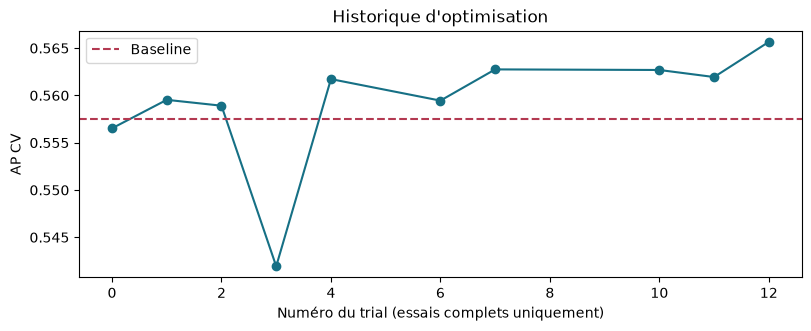

In [4]:
trial_rows = []
for t in study.trials:
    row = {'Trial': t.number, 'État': t.state.name}
    if t.state == optuna.trial.TrialState.COMPLETE:
        row['AP CV'] = t.value
    trial_rows.append(row)
trial_table = pd.DataFrame(trial_rows)
display(trial_table.style.hide(axis='index'))

fig, ax = plt.subplots(figsize=(8, 3.2), layout='constrained')
completed_sorted = sorted(completed, key=lambda t: t.number)
ax.plot([t.number for t in completed_sorted], [t.value for t in completed_sorted], marker='o', color='#167085')
ax.axhline(baseline_result.cv_result.cv_ap, color='#B33951', linestyle='--', label='Baseline')
ax.set(xlabel='Numéro du trial (essais complets uniquement)', ylabel='AP CV', title='Historique d\'optimisation')
ax.legend()
plt.show()

**Importance des hyperparamètres (fANOVA).** Cette importance est une part de variation des scores sur
les essais réalisés — ni une causalité, ni l'importance des features d'entrée du modèle (celle-ci vient de
SHAP, partie 4). Avec peu d'essais, son classement reste exploratoire.

Hyperparamètre,Importance relative
max_features_choice,2.4%
n_estimators,5.3%
min_samples_leaf,8.5%
min_samples_split,10.4%
max_depth,73.4%


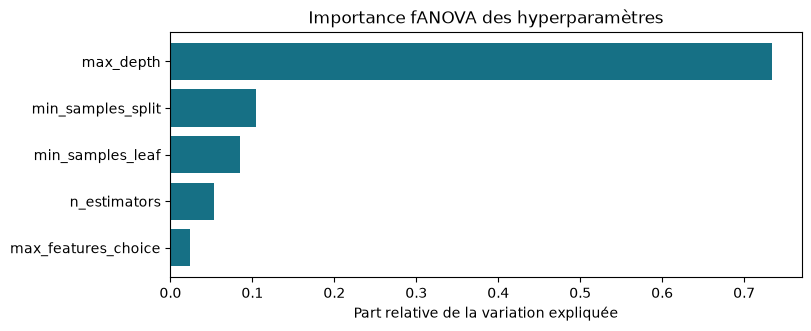

In [5]:
importances = tune.importance_table(study, seed=SEED)
importance_frame = pd.DataFrame(
    [{'Hyperparamètre': k, 'Importance relative': v} for k, v in importances.items()]
).sort_values('Importance relative')
display(importance_frame.style.hide(axis='index').format({'Importance relative': '{:.1%}'}))

fig, ax = plt.subplots(figsize=(8, 3.2), layout='constrained')
ax.barh(importance_frame['Hyperparamètre'], importance_frame['Importance relative'], color='#167085')
ax.set(xlabel="Part relative de la variation expliquée", title='Importance fANOVA des hyperparamètres')
plt.show()

🔎 **Point de réflexion.** Sur un signal faible (les features de maintenance sont peu déterminantes,
comme rappelé dans la consigne B7), le gain de tuning reste souvent petit. Comparez l'écart AP CV ci-dessus
au coût en essais et en temps : à partir de quand l'amélioration ne « vaut »-elle plus le calcul dépensé ?
C'est exactement la question de la partie suivante.

## 3. Partie B — Éco-conception avec CodeCarbon : étude lourde vs étude frugale

**Simplification assumée.** La consigne propose de comparer un large espace de recherche sans pruning à un
espace resserré avec pruning agressif. Pour rester dans le temps de ce TP, l'espace de recherche reste
**identique** entre les deux études ; seuls le budget d'essais et la stratégie de pruning varient — ce qui
suffit à observer l'effet du pruning sur le coût.

Étude,Essais,Élagués,AP CV,Durée (s),gCO2eq,Coût par point d'AP (gCO2eq)
Baseline,1,0,0.5575,28.0,0.044,inf
Lourde (sans pruning),8,0,0.5658,335.7,0.551,66.7
Frugale (pruning agressif),8,4,0.5644,128.7,0.210,30.9


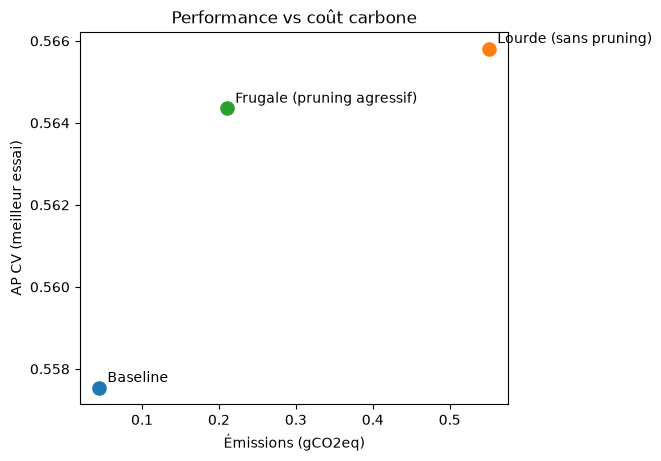

In [6]:
def run_heavy_study():
    heavy_objective = tune.make_objective(split.X['train'], split.y['train'], folds, seed=SEED)
    return tune.run_study(
        heavy_objective, budget=tune.StudyBudget(n_trials=8, timeout=None, n_startup_trials=3),
        seed=SEED, study_name='b7-etude-lourde', pruner=optuna.pruners.NopPruner(),
    )

def run_frugal_study():
    frugal_objective = tune.make_objective(split.X['train'], split.y['train'], folds, seed=SEED)
    return tune.run_study(
        frugal_objective, budget=tune.StudyBudget(n_trials=8, timeout=None, n_startup_trials=1),
        seed=SEED, study_name='b7-etude-frugale',
        pruner=optuna.pruners.MedianPruner(n_startup_trials=1, n_warmup_steps=0),
    )

heavy_study, heavy_carbon = carbon.track_step(
    run_heavy_study, step='etude_lourde', output_dir=OUTPUT_DIR, project_name='indusense-fault-notebook',
)
frugal_study, frugal_carbon = carbon.track_step(
    run_frugal_study, step='etude_frugale', output_dir=OUTPUT_DIR, project_name='indusense-fault-notebook',
)

for run in (baseline_carbon, study_carbon, heavy_carbon, frugal_carbon):
    carbon.append_summary_row(OUTPUT_DIR / 'emissions_summary.csv', run, run_name='b7-notebook')

comparison_rows = [
    {'Étude': 'Baseline', 'Essais': 1, 'Élagués': 0, 'AP CV': baseline_result.cv_result.cv_ap,
     'Durée (s)': baseline_carbon.duration_seconds, 'gCO2eq': baseline_carbon.emissions_kg * 1000},
    {'Étude': 'Lourde (sans pruning)', 'Essais': len(heavy_study.trials),
     'Élagués': sum(t.state == optuna.trial.TrialState.PRUNED for t in heavy_study.trials),
     'AP CV': heavy_study.best_value, 'Durée (s)': heavy_carbon.duration_seconds,
     'gCO2eq': heavy_carbon.emissions_kg * 1000},
    {'Étude': 'Frugale (pruning agressif)', 'Essais': len(frugal_study.trials),
     'Élagués': sum(t.state == optuna.trial.TrialState.PRUNED for t in frugal_study.trials),
     'AP CV': frugal_study.best_value, 'Durée (s)': frugal_carbon.duration_seconds,
     'gCO2eq': frugal_carbon.emissions_kg * 1000},
]
comparison_table = pd.DataFrame(comparison_rows)
comparison_table['Coût par point d\'AP (gCO2eq)'] = [
    carbon.cost_per_performance_point(baseline_result.cv_result.cv_ap, row['AP CV'], row['gCO2eq'] / 1000) * 1000
    for row in comparison_rows
]
display(comparison_table.style.hide(axis='index').format({
    'AP CV': '{:.4f}', 'Durée (s)': '{:.1f}', 'gCO2eq': '{:.3f}', "Coût par point d'AP (gCO2eq)": '{:.1f}',
}))

fig, ax = plt.subplots(figsize=(6.5, 4.5), layout='constrained')
for _, row in comparison_table.iterrows():
    ax.scatter(row['gCO2eq'], row['AP CV'], s=90)
    ax.annotate(row['Étude'], (row['gCO2eq'], row['AP CV']), textcoords='offset points', xytext=(6, 4))
ax.set(xlabel='Émissions (gCO2eq)', ylabel='AP CV (meilleur essai)', title='Performance vs coût carbone')
plt.show()

🔎 **Point de réflexion clé.** Lisez le tableau : l'étude lourde apporte-t-elle un gain d'AP
**proportionné** à son surcoût carbone par rapport à la frugale ? Si le coût par point d'AP explose sans gain
net, la **parcimonie** (moins d'essais, pruning agressif, voire un modèle plus simple) est la meilleure
décision Green AI dans ce contexte — c'est un jugement à faire sur les chiffres ci-dessus, pas une réponse
universelle.

## 4. Partie C — Explicabilité avec SHAP

Le modèle expliqué est le **meilleur des deux** (baseline vs étude principale bornée), retenu s'il bat
strictement la baseline sur l'AP CV — sinon la baseline reste le candidat le plus honnête.

In [7]:
if study.best_value > baseline_result.cv_result.cv_ap:
    decoded_best = model.decode_params(study.best_params)
    best_result = train.fit_and_log(
        decoded_best, split.X['train'], split.y['train'], folds,
        role='tuned', seed=SEED, logged_params=study.best_params,
        mlflow_run=mlflow.start_run(run_name='b7-tuned', nested=True),
    )
    best_label = 'tuned'
else:
    best_result = baseline_result
    best_label = 'baseline'

val_scores = best_result.model.predict_proba(split.X['validation'])[:, 1]
threshold = evaluate.choose_threshold(split.y['validation'], val_scores)
validation_metrics = evaluate.evaluate_at_threshold(split.y['validation'], val_scores, threshold)
test_scores = best_result.model.predict_proba(split.X['test'])[:, 1]
test_metrics = evaluate.evaluate_at_threshold(split.y['test'], test_scores, threshold)

display(Markdown(
    f"**Modèle retenu pour l'explicabilité : {best_label}.** AP CV {best_result.cv_result.cv_ap:.4f} ; "
    f"validation F2 {validation_metrics.F2:.4f} ; test AP {test_metrics.AP:.4f}, F2 {test_metrics.F2:.4f}."
))

**Modèle retenu pour l'explicabilité : tuned.** AP CV 0.5657 ; validation F2 0.5491 ; test AP 0.6026, F2 0.5583.

feature,impact,direction
incident_count_prev_24h,0.0731,-1
hours_since_last_incident,0.0702,-1
temp_mean_24h,0.0249,-1
incident_count_prev_7d,0.0229,-1
temp_max_24h,0.0205,-1
incident_max_severity_prev_24h,0.0142,-1
rotation_max_24h,0.0087,+1
pressure_mean_24h,0.0073,-1
days_since_last_maintenance,0.0055,+1
temp_max_12h,0.0048,-1


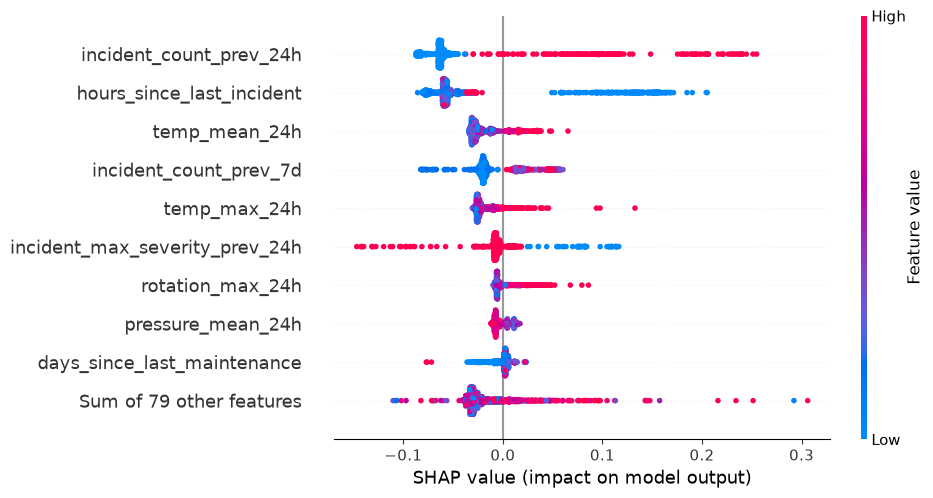

In [8]:
X_val_sample = split.X['validation'].sample(n=min(1000, len(split.X['validation'])), random_state=SEED)
explanation = explain.build_explanation(best_result.model, X_val_sample)
top = explain.top_features(explanation, n=10)
display(top.style.hide(axis='index').format({'impact': '{:.4f}', 'direction': '{:+.0f}'}))

shap.plots.beeswarm(explanation, show=False)
plt.gcf().savefig(FIGURES_DIR / 'shap_summary.png', bbox_inches='tight', dpi=150)
plt.show()

🔎 **Point de réflexion.** Une feature anormalement dominante (qui « explique tout ») doit alerter :
vérifier une fuite (corrélation feature ↔ futur), à rapprocher de la checklist anti-leakage du Gold. Ici,
comparez l'impact de la feature n°1 à celui des suivantes : l'impact est-il concentré ou diffus ?

**Cas expliqué localement :** position 568 (score 0.982).

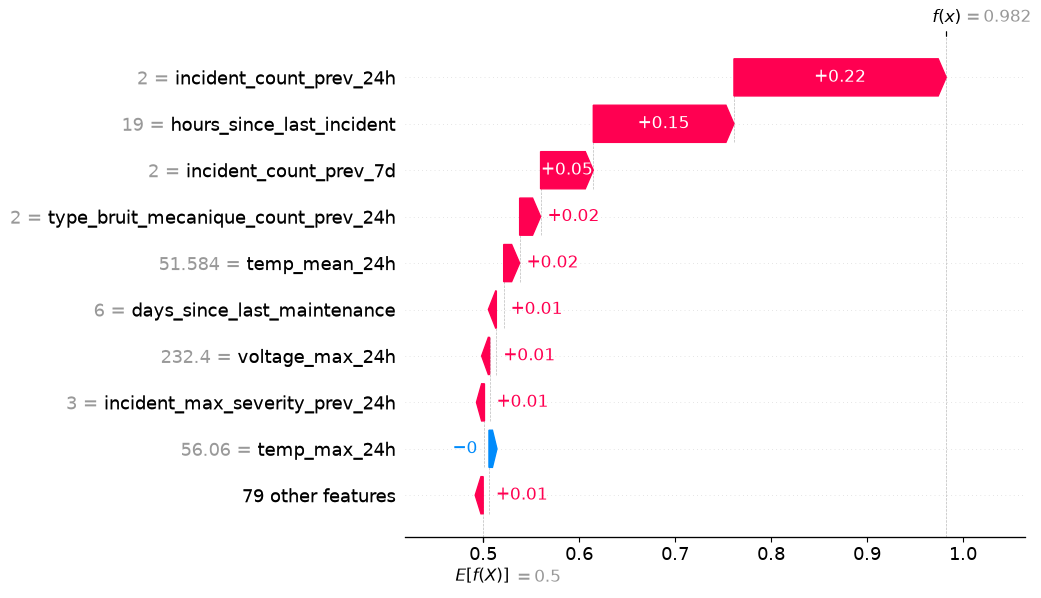

In [9]:
sample_scores = best_result.model.predict_proba(X_val_sample)[:, 1]
flagged = explain.pick_flagged_instance(sample_scores, X_val_sample, threshold=threshold)
display(Markdown(f"**Cas expliqué localement :** position {flagged.position} (score {flagged.score:.3f})."))

shap.plots.waterfall(explanation[flagged.position], show=False)
plt.gcf().savefig(FIGURES_DIR / 'shap_waterfall.png', bbox_inches='tight', dpi=150)
plt.show()

**Confrontation à l'intuition métier :** relire les features listées dans le waterfall ci-dessus —
sont-elles plausibles (température, incidents récents, temps depuis la dernière maintenance) ou
surprenantes ? Une feature surprenante en tête doit être documentée, pas ignorée.

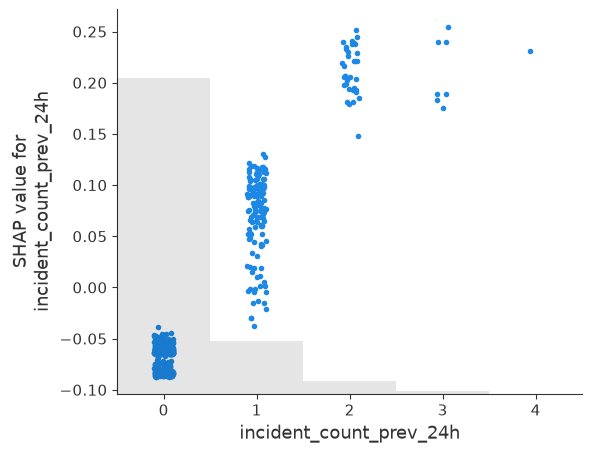

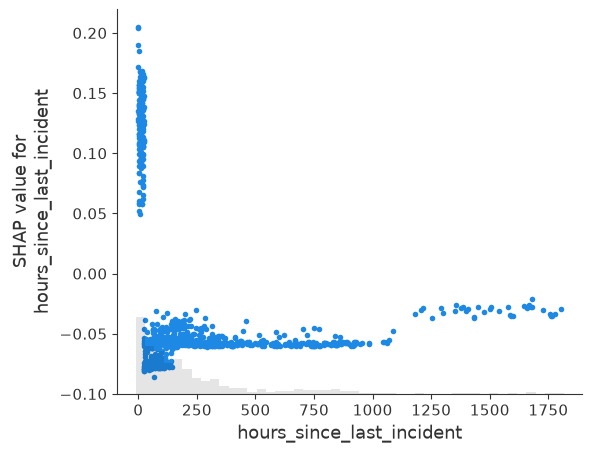

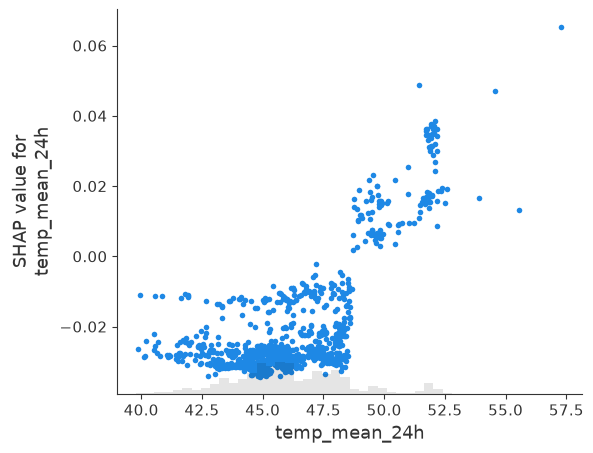

**Diagnostic concentré vs diffus.** La feature n°1 pèse **29.0%** de la somme des 10 impacts les plus forts. Impact diffus sur de nombreuses features faibles : peu de signal individuel fort, cohérent avec l'avertissement de la consigne sur ce jeu de données.

In [10]:
dependence_features = explain.dependence_pairs(top, n=3)
for feature in dependence_features:
    shap.plots.scatter(explanation[:, feature], show=False)
    plt.gcf().savefig(FIGURES_DIR / f'shap_dependence_{feature}.png', bbox_inches='tight', dpi=150)
    plt.show()

concentration = top['impact'].iloc[0] / top['impact'].sum()
display(Markdown(
    f"**Diagnostic concentré vs diffus.** La feature n°1 pèse **{concentration:.1%}** de la somme des "
    f"10 impacts les plus forts. " + (
        "Impact concentré sur peu de features : un signal clair existe."
        if concentration > 0.35 else
        "Impact diffus sur de nombreuses features faibles : peu de signal individuel fort, cohérent avec "
        "l'avertissement de la consigne sur ce jeu de données."
    )
))

## 5. Partie E — Tableau d'arbitrage et recommandation

Trois suites possibles à ce diagnostic : **(1)** retour au feature engineering (lookback plus long,
interactions), **(2)** changer d'horizon de label (48h capte parfois plus que 24h), **(3)** accepter un
modèle modeste mais honnête. Le tableau ci-dessous synthétise les chiffres qui permettent de trancher.

In [11]:
total_emissions_g = (baseline_carbon.emissions_kg + study_carbon.emissions_kg) * 1000
arbitration = evaluate.arbitration_table([{
    'modele': best_label,
    'pr_auc': test_metrics.AP,
    'gco2eq': total_emissions_g,
    'interpretabilite': f"SHAP top-1 = {top.iloc[0]['feature']} (impact {top.iloc[0]['impact']:.4f}, "
                        f"{concentration:.1%} du top 10)",
    'decision': (
        "Retenu comme candidat v1 : gain net sur baseline, coût carbone mesuré et explication cohérente."
        if best_label == 'tuned' else
        "Baseline conservée : Optuna n'apporte pas de gain net sur ce budget — signal faible confirmé, "
        "cf. diagnostic SHAP diffus. Prochaine étape recommandée : (2) tester l'horizon 48h."
    ),
}])
arbitration.to_csv(OUTPUT_DIR / 'arbitration_table_notebook.csv', index=False)
display(arbitration.style.hide(axis='index'))

print('NOTEBOOK_B7_ML_VALIDE')

modele,pr_auc,gco2eq,interpretabilite,decision
tuned,0.602641,0.556410,"SHAP top-1 = incident_count_prev_24h (impact 0.0731, 29.0% du top 10)","Retenu comme candidat v1 : gain net sur baseline, coût carbone mesuré et explication cohérente."


NOTEBOOK_B7_ML_VALIDE
